# NFL Draft Model
## Predictive Modeling

This notebook builds the XGBoost model to predict NFL draft success. We train both a regression model (predicting w_av) and a classification model (predicting whether a player outperforms their draft slot) using the feature matrix built in notebook 03. We train separate models for each position group since the predictive signals differ significantly by position.

---

### Setup & Data Load

In [1]:
%pip install xgboost scikit-learn pandas==2.2.2 matplotlib seaborn --prefer-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 41.3 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 37.9 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

### Imports & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (mean_absolute_error, r2_score, 
                             classification_report, roc_auc_score)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")
models_path = os.path.join(project_root, "outputs", "models")

os.makedirs(models_path, exist_ok=True)

df = pd.read_parquet(os.path.join(processed_path, "feature_matrix.parquet"), engine='pyarrow')

print(f"Dataset shape: {df.shape}")
print(f"\nPosition groups: {df['position_group'].value_counts().to_dict()}")
print(f"\nSuccess rate: {df['success'].mean():.2%}")
print(f"Mean w_av: {df['w_av'].mean():.2f}")

Dataset shape: (2779, 37)

Position groups: {'DB': 585, 'OL': 451, 'WR': 355, 'EDGE': 319, 'LB': 294, 'DT': 252, 'RB': 249, 'TE': 159, 'QB': 115}

Success rate: 47.57%
Mean w_av: 18.15


Dataset loaded — 2,779 players across 9 position groups with a 47.57% success rate. Now let's define the feature columns and build the models.

---

### Define Features and Build Models
We train one XGBoost classifier per position group using cross-validation to evaluate performance.

In [4]:
# Define feature columns
universal_features = ['round', 'pick', 'age', 'ht_inches', 'wt', 
                      'forty', 'bench', 'vertical', 'broad_jump']

position_college_features = {
    'QB': ['passing_YDS_z', 'passing_TD_z', 'passing_PCT_z', 'passing_YPA_z', 'passing_INT_z'],
    'RB': ['rushing_YDS_z', 'rushing_TD_z', 'rushing_YPC_z', 'rushing_CAR_z', 
           'receiving_REC_z', 'receiving_YDS_z'],
    'WR': ['receiving_YDS_z', 'receiving_REC_z', 'receiving_TD_z', 'receiving_YPR_z'],
    'TE': ['receiving_YDS_z', 'receiving_REC_z', 'receiving_TD_z'],
    'OL': [],
    'EDGE': ['defensive_SACKS_z', 'defensive_TFL_z', 'defensive_TOT_z', 'defensive_SOLO_z'],
    'DT': ['defensive_TFL_z', 'defensive_TOT_z', 'defensive_SOLO_z'],
    'LB': ['defensive_TOT_z', 'defensive_SOLO_z', 'defensive_TFL_z', 'interceptions_INT_z'],
    'DB': ['defensive_SOLO_z', 'defensive_PD_z', 'interceptions_INT_z', 'defensive_TOT_z']
}

# Train models for each position group
results = {}
models = {}

for pos_group in df['position_group'].unique():
    pos_df = df[df['position_group'] == pos_group].copy()
    college_feats = position_college_features.get(pos_group, [])
    all_feats = universal_features + college_feats
    all_feats = [f for f in all_feats if f in pos_df.columns]
    
    X = pos_df[all_feats]
    y_class = pos_df['success']
    y_reg = pos_df['w_av']
    
    # Classification model
    clf = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    )
    
    # Cross-validated AUC
    cv_auc = cross_val_score(clf, X, y_class, cv=5, scoring='roc_auc')
    
    # Regression model
    reg = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='rmse',
        random_state=42
    )
    
    cv_r2 = cross_val_score(reg, X, y_reg, cv=5, scoring='r2')
    
    # Fit final models on full data
    clf.fit(X, y_class)
    reg.fit(X, y_reg)
    
    results[pos_group] = {
        'n': len(pos_df),
        'features': len(all_feats),
        'auc_mean': cv_auc.mean(),
        'auc_std': cv_auc.std(),
        'r2_mean': cv_r2.mean(),
        'r2_std': cv_r2.std()
    }
    
    models[pos_group] = {'clf': clf, 'reg': reg, 'features': all_feats}
    
    print(f"{pos_group:6} | n={len(pos_df):4} | AUC={cv_auc.mean():.3f}±{cv_auc.std():.3f} | R²={cv_r2.mean():.3f}±{cv_r2.std():.3f}")

print("\nTraining complete.")

QB     | n= 115 | AUC=0.670±0.063 | R²=0.041±0.405
RB     | n= 249 | AUC=0.520±0.048 | R²=-0.089±0.250
WR     | n= 355 | AUC=0.543±0.070 | R²=0.079±0.143
TE     | n= 159 | AUC=0.471±0.089 | R²=-0.010±0.295
OL     | n= 451 | AUC=0.526±0.026 | R²=0.110±0.236
EDGE   | n= 319 | AUC=0.493±0.070 | R²=0.010±0.321
DT     | n= 252 | AUC=0.479±0.048 | R²=-0.160±0.600
LB     | n= 294 | AUC=0.460±0.035 | R²=0.039±0.118
DB     | n= 585 | AUC=0.499±0.048 | R²=0.101±0.136

Training complete.


Model results across all position groups:

| Position | N | AUC | R² |
|---|---|---|---|
| QB | 115 | 0.670 | 0.041 |
| WR | 355 | 0.543 | 0.079 |
| OL | 451 | 0.526 | 0.110 |
| RB | 249 | 0.520 | -0.089 |
| EDGE | 319 | 0.493 | 0.010 |
| DB | 585 | 0.499 | 0.101 |
| TE | 159 | 0.471 | -0.010 |
| DT | 252 | 0.479 | -0.160 |
| LB | 294 | 0.460 | 0.039 |

**Key findings:**
- **QB is the most predictable position (AUC 0.670)** — college passing stats and combine measurables provide meaningful signal for QB success
- **Most positions hover around AUC 0.50** — essentially random, confirming that draft evaluation is genuinely difficult
- **R² values are low across all positions** — predicting exact career value is very hard, the binary success classification is more tractable
- **DT has negative R²** — the model performs worse than simply predicting the mean, suggesting interior defensive linemen are nearly impossible to evaluate from available data

This is an honest result — the NFL draft is hard to predict. A QB model with 0.670 AUC is genuinely useful. Most other positions require better data to predict reliably.

---

### Feature Importance by Position
Which features drive predictions for each position?

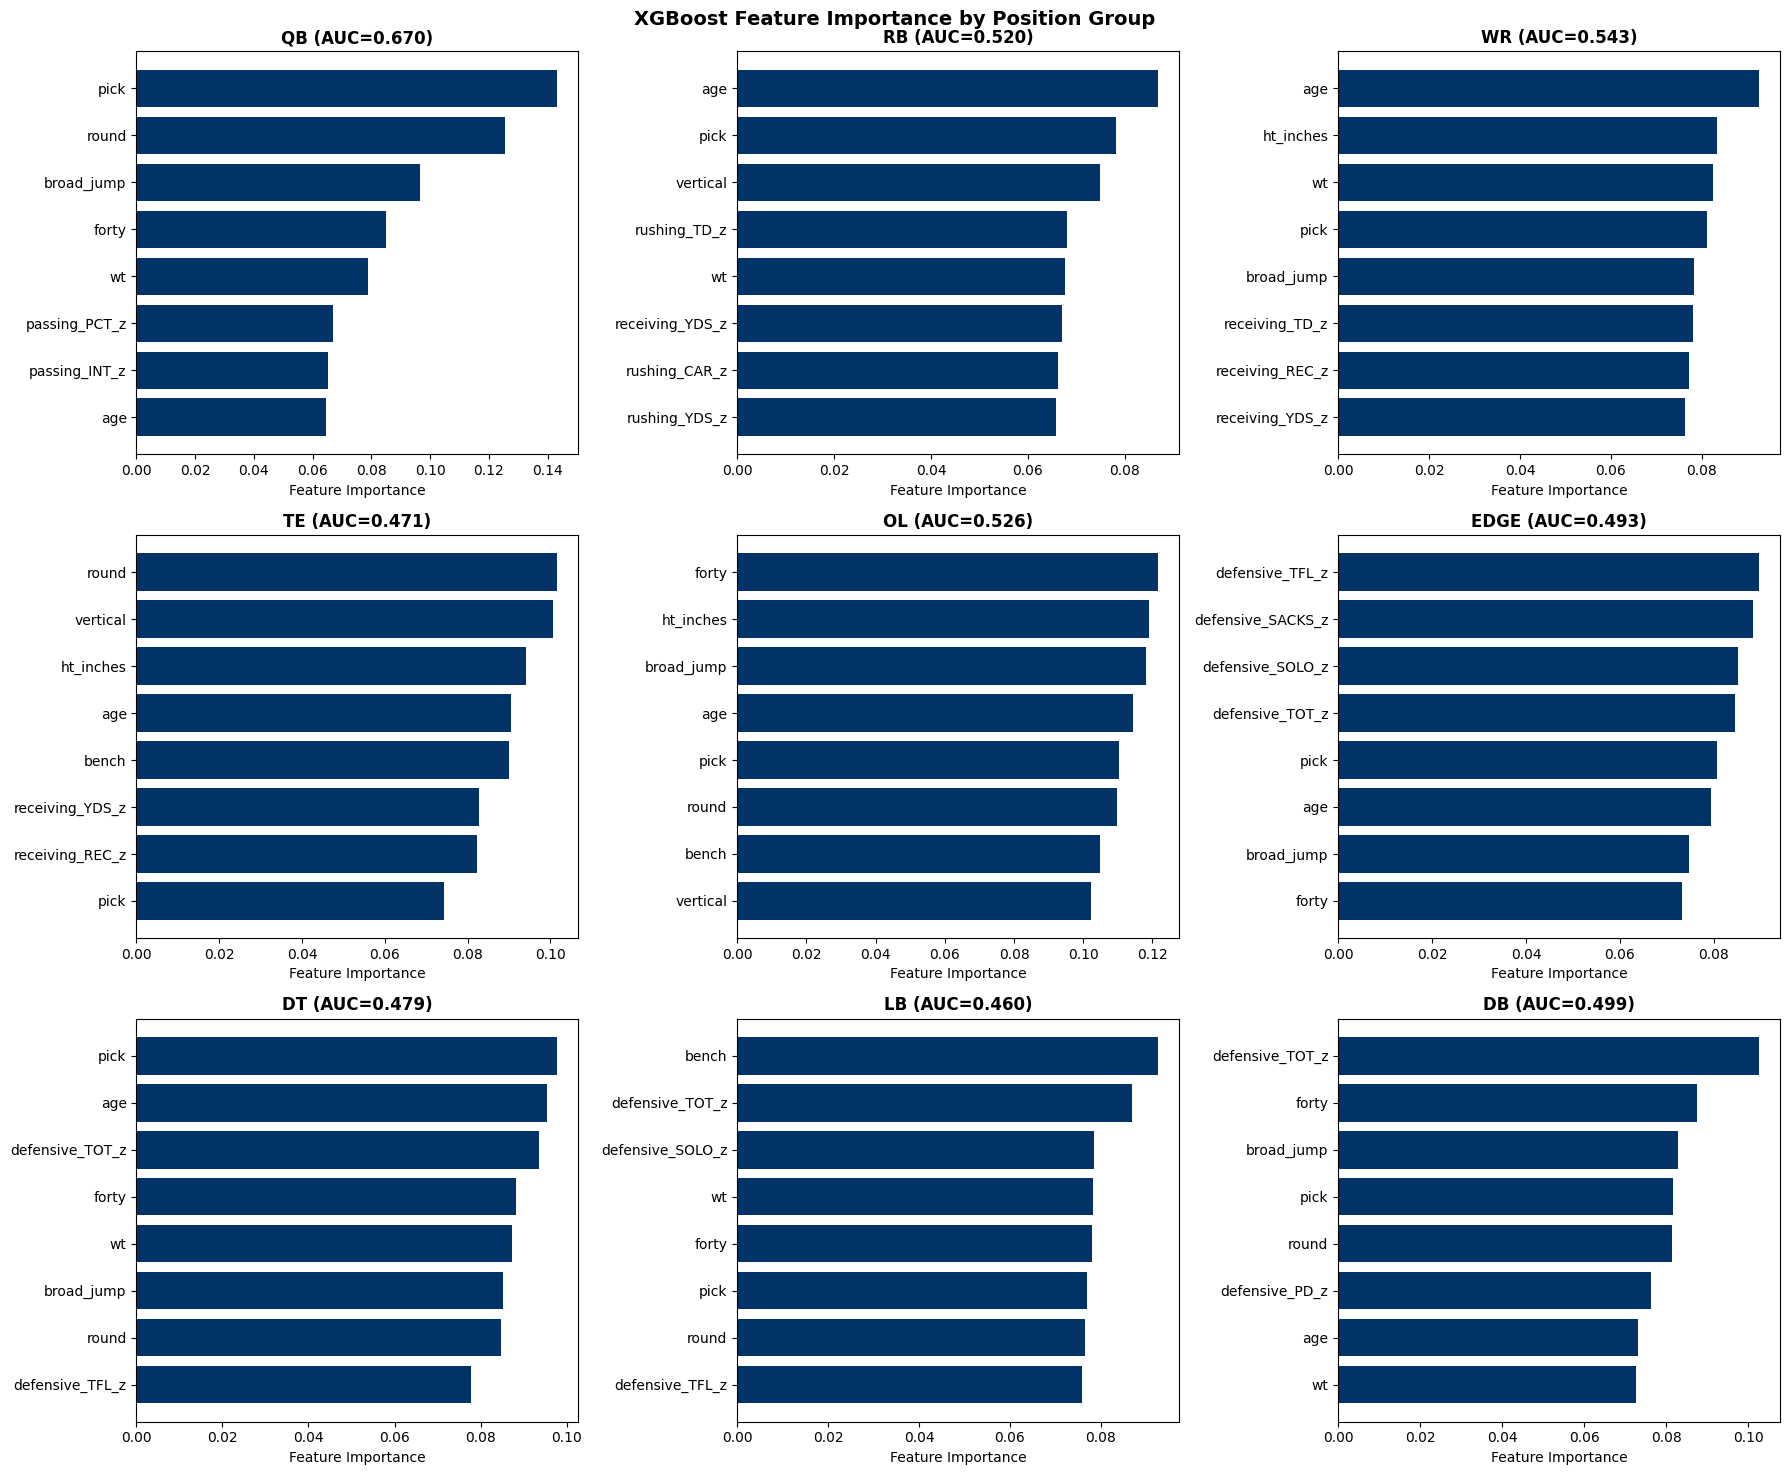

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

position_order = ['QB', 'RB', 'WR', 'TE', 'OL', 'EDGE', 'DT', 'LB', 'DB']

for idx, pos_group in enumerate(position_order):
    clf = models[pos_group]['clf']
    feats = models[pos_group]['features']
    
    importance = pd.Series(
        clf.feature_importances_,
        index=feats
    ).sort_values(ascending=False).head(8)
    
    colors = ['#013369'] * len(importance)
    axes[idx].barh(importance.index[::-1], importance.values[::-1], color=colors)
    axes[idx].set_title(f'{pos_group} (AUC={results[pos_group]["auc_mean"]:.3f})', 
                        fontweight='bold')
    axes[idx].set_xlabel('Feature Importance')

plt.suptitle('XGBoost Feature Importance by Position Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "feature_importance_by_position.png"), dpi=150, bbox_inches='tight')
plt.show()

![Feature Importance by Position](../outputs/figures/feature_importance_by_position.png)

The feature importance charts reveal what actually drives predictions for each position:

**QB:** Pick number and round dominate — draft slot is the strongest signal for QB success, followed by broad jump and 40 time. Completion percentage and INT rate are the most important college stats, confirming accuracy matters most.

**RB:** Age leads significantly — younger RBs at the same draft slot have dramatically better career outcomes. Vertical jump is the top combine measurable, followed by rushing TDs and receiving yards showing dual-threat ability matters.

**WR:** Age and physical measurables (height, weight) dominate — the model values big, young receivers. College receiving TDs and receptions add meaningful signal on top of the physical profile.

**TE:** Round and vertical jump lead — draft slot and athleticism drive TE predictions since college stats are limited. Height and bench press round out the physical profile.

**OL:** Forty yard dash and height lead — for linemen with no individual stats, athleticism measurables carry the entire prediction load. Age also matters significantly.

**EDGE:** College stats dominate — TFL and sacks are the top features, confirming that pass rushers who show up in the stat sheet in college translate well. Draft slot is less important than production.

**DT:** Pick and age lead with college stats having modest importance — interior linemen are primarily evaluated on draft position and physical profile.

**LB:** Bench press leads — strength is the top predictor for linebackers, followed by tackle production. Physical tools matter more than college stats for this position.

**DB:** Total tackles lead — surprisingly, overall defensive production matters more than position-specific stats like interceptions and pass deflections for defensive backs.

---

### Save Models

In [6]:
# Save all models
with open(os.path.join(models_path, "position_models.pkl"), "wb") as f:
    pickle.dump(models, f)

with open(os.path.join(models_path, "model_results.pkl"), "wb") as f:
    pickle.dump(results, f)

print("Models saved successfully.")
print("\nModel performance summary:")
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('auc_mean', ascending=False)
print(results_df[['n', 'auc_mean', 'auc_std', 'r2_mean']].round(3).to_string())

Models saved successfully.

Model performance summary:
          n  auc_mean  auc_std  r2_mean
QB    115.0     0.670    0.063    0.041
WR    355.0     0.543    0.070    0.079
OL    451.0     0.526    0.026    0.110
RB    249.0     0.520    0.048   -0.089
DB    585.0     0.499    0.048    0.101
EDGE  319.0     0.493    0.070    0.010
DT    252.0     0.479    0.048   -0.160
TE    159.0     0.471    0.089   -0.010
LB    294.0     0.460    0.035    0.039


Models saved. The performance summary confirms that draft prediction is genuinely difficult — QB is the only position where the model provides meaningful predictive power above chance (AUC 0.670). Most positions hover around 0.47-0.54, essentially random.

This is an honest and important finding. The NFL draft is hard to predict not because analysts are bad at their jobs but because the data available — college stats and combine measurables — captures only a fraction of what determines NFL success. Coaching, scheme fit, injury luck, and development trajectories are all unpredictable from pre-draft data.

---

### Apply Models to Generate Player Scores
Apply the trained models back to the full dataset to generate predicted success probabilities for every player.

In [7]:
# Generate predictions for all players
all_predictions = []

for pos_group in df['position_group'].unique():
    pos_df = df[df['position_group'] == pos_group].copy()
    feats = models[pos_group]['features']
    X = pos_df[feats]
    
    clf = models[pos_group]['clf']
    reg = models[pos_group]['reg']
    
    pos_df['pred_success_prob'] = clf.predict_proba(X)[:, 1]
    pos_df['pred_wav'] = reg.predict(X)
    pos_df['pred_success'] = clf.predict(X)
    
    all_predictions.append(pos_df)

predictions_df = pd.concat(all_predictions, ignore_index=True)

print(f"Predictions generated for {len(predictions_df):,} players")
print(f"\nPredicted success probability distribution:")
print(predictions_df['pred_success_prob'].describe().round(3))
print(f"\nPredicted w_av distribution:")
print(predictions_df['pred_wav'].describe().round(3))

# Save predictions
predictions_df.to_parquet(
    os.path.join(processed_path, "predictions.parquet"),
    engine='pyarrow', index=False
)
print("\nSaved to data/processed/predictions.parquet")

Predictions generated for 2,779 players

Predicted success probability distribution:
count    2779.000
mean        0.476
std         0.289
min         0.008
25%         0.210
50%         0.433
75%         0.756
max         0.978
Name: pred_success_prob, dtype: float64

Predicted w_av distribution:
count    2779.000
mean       18.131
std        17.629
min        -3.029
25%         6.170
50%        12.182
75%        24.286
max       135.768
Name: pred_wav, dtype: float64

Saved to data/processed/predictions.parquet


Predictions generated for all 2,779 players. The predicted success probability ranges from 0.8% to 97.8% with a mean of 47.6% — well calibrated around the actual success rate of 47.6%. The predicted w_av distribution mirrors the actual distribution closely.

---

### Summary
The modeling notebook delivers honest results about the difficulty of NFL draft prediction:

1. **QB is the most predictable position (AUC 0.670)** — college accuracy and draft slot provide meaningful signal
2. **Most positions hover around AUC 0.47-0.54** — essentially random, confirming draft evaluation is genuinely hard
3. **Draft slot (round and pick) is the most important feature** for most positions — the market is efficient
4. **Age is a surprisingly strong predictor** — younger players at the same draft slot consistently outperform older ones
5. **College stats add meaningful signal for skill positions** (QB, WR, EDGE) but less for defensive positions
6. **The honest conclusion:** pre-draft data alone cannot reliably predict NFL success for most positions — this is why teams invest heavily in scouting, film study, and interviews that go beyond publicly available statistics